# Rayleigh-Taylor instability of a Navier-Stokes fluid in a rectangle

$$
\mathbb{S}
\begin{cases}
\Omega = [0, \mathcal{A}X] \times [0, X] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1) \\
\textbf{e}_g=-\textbf{e}_y & \text{vertically downward gravity} \\
c_0(x, y)=\text{H}(y-\tfrac{1}{2}X)+\mathcal{N}(x,y) & \text{perturbed initial stratification} \\
\textbf{u}_0 = \textbf{0} \\
p_0 = 0 \\
c_{\text{N}}\vert_{\partial\Omega}=0 & \text{no-flux on entire boundary} \\
\textbf{u}_{\text{E}}\vert_{\partial\Omega}=\textbf{0} & \text{no-flow on entire boundary} \\
\rho(c) = c & \text{linear density} \\
\mu=1 & \text {constant viscosity} 
\end{cases}
$$

In [ ]:
from lucifex.sim import run
from lucifex.utils.array_utils import as_indices
from lucifex.viz import plot_colormap, create_animation, save_figure, display_animation
from py.C03_navier_stokes_rayleigh_taylor import navier_stokes_rayleigh_taylor_rectangle

Ra = 1e5
simulation = navier_stokes_rayleigh_taylor_rectangle(
    aspect=2.0,    
    Nx=64,
    Ny=64,
    Ra=Ra,
    dt_max=0.01, 
)

n_stop = 400
dt_init = 1e-6
n_init = 10
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c = simulation['c']
mesh = c.mesh

In [2]:
time_slice = slice(0, None, 2)
titles = [f'$c(t={t:.3f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'{c.name}(x,y,t)', get_path=True)(anim)

display_animation(anim_path)

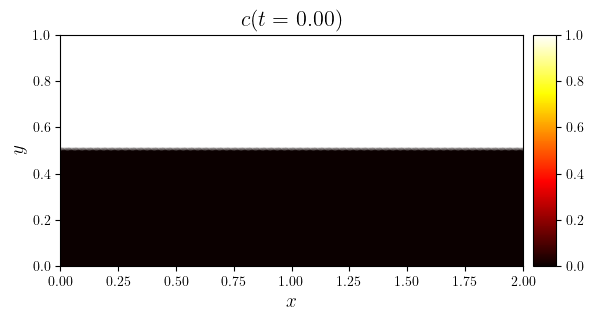

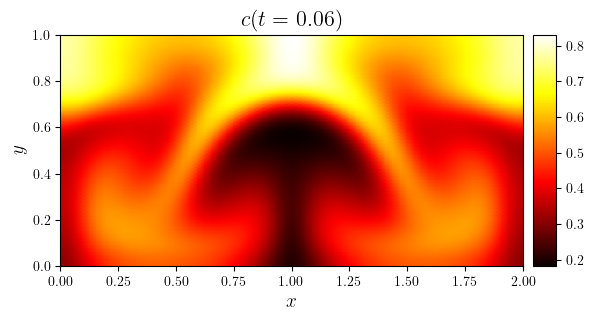

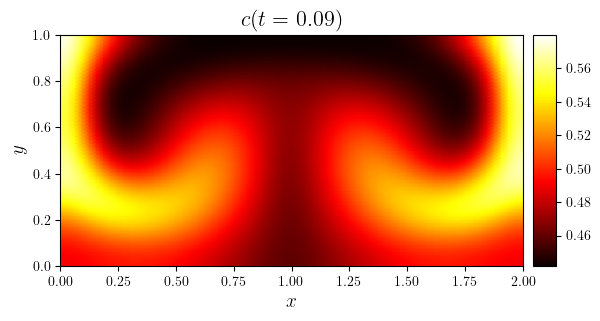

In [3]:
time_indices = as_indices(c.time_series, (0, 0.5, -1), fraction=True)
for i in time_indices:
    t = c.time_series[i]
    fig, ax = plot_colormap(c.series[i], title=f'$c(t={t:.2f})$')
    save_figure(f'c(x,y,t={c.time_series[i]:.3f})', thumbnail=(i == -1))(fig)